In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [11]:
# 1. Load the dataset
df = pd.read_csv('all_stocks_5yr.csv')

# Isolate a single stock (e.g., Apple) to train a specific model
stock_df = df[df['Name'] == 'AAPL'].copy()

# Ensure data is sorted chronologically
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df.sort_values('date', inplace=True)

stock_df.head()

,date,open,high,low,close,volume,Name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [12]:
# 2. Define the Target Variable
# If tomorrow's close is strictly greater than today's close, it's a 1 (UP). Else 0 (DOWN).
# We use .shift(-1) to pull tomorrow's price into today's row for comparison.
stock_df['Target'] = (stock_df['close'].shift(-1) > stock_df['close']).astype(int)

# 3. Feature Engineering (Giving the forest indicators to look at)
stock_df['Daily_Return'] = stock_df['close'].pct_change()
stock_df['5_Day_MA'] = stock_df['close'].rolling(window=5).mean()
stock_df['10_Day_MA'] = stock_df['close'].rolling(window=10).mean()
stock_df['Volume_Change'] = stock_df['volume'].pct_change()

# Drop the rows that now have NaN values due to the rolling windows and shifts
stock_df.dropna(inplace=True)

# Define our feature columns
features = ['open', 'high', 'low', 'close', 'volume', 'Daily_Return', '5_Day_MA', '10_Day_MA', 'Volume_Change']
X = stock_df[features]
y = stock_df['Target']

stock_df.head()

,date,open,high,low,close,volume,Name,Target,Daily_Return,5_Day_MA,10_Day_MA,Volume_Change
1268,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,0,0.010649,64.73910,66.03251,-0.259981
1269,2013-02-25,64.8356,65.0171,63.2242,63.2571,92899597,AAPL,1,-0.017768,64.24310,65.57280,0.124913
1270,2013-02-26,63.4028,64.5056,62.5228,64.1385,125096657,AAPL,0,0.013934,63.92824,65.13051,0.346579
1271,2013-02-27,64.0614,64.6342,62.9499,63.5099,146674682,AAPL,0,-0.009801,63.80594,64.79722,0.172491
1272,2013-02-28,63.4357,63.9814,63.0571,63.0571,80532382,AAPL,0,-0.007130,63.67280,64.43137,-0.450946


In [13]:
# Train on the first 80% of the timeline, test on the final 20%
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [17]:
# Initialize the model
# n_estimators = 100 (We are growing 100 decision trees)
# max_depth = 5 (Limits how deep/complex each tree can get to prevent overfitting)
# random_state ensures you get the exact same results every time you run the code
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Make predictions on the test set
predictions = rf_model.predict(X_test)

# Print the results
print("Accuracy Score:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy Score: 0.476

Classification Report:
               precision    recall  f1-score   support

           0       0.48      1.00      0.64       119
           1       0.00      0.00      0.00       131

    accuracy                           0.48       250
   macro avg       0.24      0.50      0.32       250
weighted avg       0.23      0.48      0.31       250



/opt/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


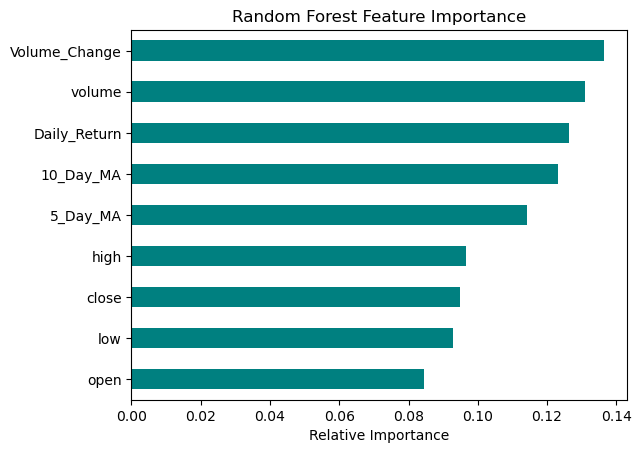

In [20]:
# Extract feature importances
importances = pd.Series(rf_model.feature_importances_, index=features)

# Plot the top features
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Random Forest Feature Importance")
plt.xlabel("Relative Importance")
plt.show()